## **HABER BAŞLIKLARININ MAKİNE ÖĞRENMESİ YÖNTEMLERİ İLE SINIFLANDIRILMASI**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.feature_selection import SelectKBest, chi2
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, label_binarize, normalize

from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from xgboost import XGBClassifier

from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, roc_auc_score, roc_curve, auc, cohen_kappa_score)

In [2]:
def specificity_score(y_true, y_pred, kategoriler):
    cm = confusion_matrix(y_true, y_pred, labels=kategoriler)
    specificity_list = []
    for i in range(len(kategoriler)):
        tn = cm.sum() - cm[i,:].sum() - cm[:,i].sum() + cm[i,i]
        fp = cm[:,i].sum() - cm[i,i]
        specificity_list.append(tn / (tn + fp) if (tn + fp) > 0 else 0)
    return np.mean(specificity_list)

In [3]:
df = pd.read_csv('/content/drive/MyDrive/YapayZeka/news_data.csv')

print("Satır sayısı:", len(df))
print("Sütunlar:", df.columns.tolist())
print()
df.head()

Satır sayısı: 48322
Sütunlar: ['title', 'topic', 'genre', 'source', 'date']



,title,topic,genre,source,date
0,What Women Need To Know About The Rise Of ADHD...,Health & Medicine,Informational,Forbes,2025-10-01T00:59:06Z
1,American Airlines Unveils Limited-Edition Rave...,Business & Economy,Informational,Forbes,2025-10-01T00:58:28Z
2,"Here's How the S&P 500, Nasdaq, and Dow Jones ...",Business & Economy,Informational,TheStreet,2025-10-01T00:53:09Z
3,Character.AI removes Disney characters from pl...,Technology & Science,Informational,NBC News,2025-10-01T00:53:07Z
4,The Timeless Beauty Of Roméo Et Juliette,Entertainment & Culture,Informational,Forbes,2025-10-01T00:52:09Z


In [4]:
print("Kategori dağılımı:")
print(df['topic'].value_counts())
print()
print("Eksik değer var mı:")
print(df.isnull().sum())
if df.isnull().sum().sum() == 0:
    print("Eksik değer yok.")

Kategori dağılımı:
topic
Politics & Government      9930
Business & Economy         9753
Sports                     8955
Technology & Science       5092
Entertainment & Culture    4170
Society & Lifestyle        3470
Crime & Law                3274
Environment & Climate      1710
Health & Medicine          1487
Education                   481
Name: count, dtype: int64

Eksik değer var mı:
title     0
topic     0
genre     0
source    0
date      0
dtype: int64
Eksik değer yok.


**Kategori Dağılımı**

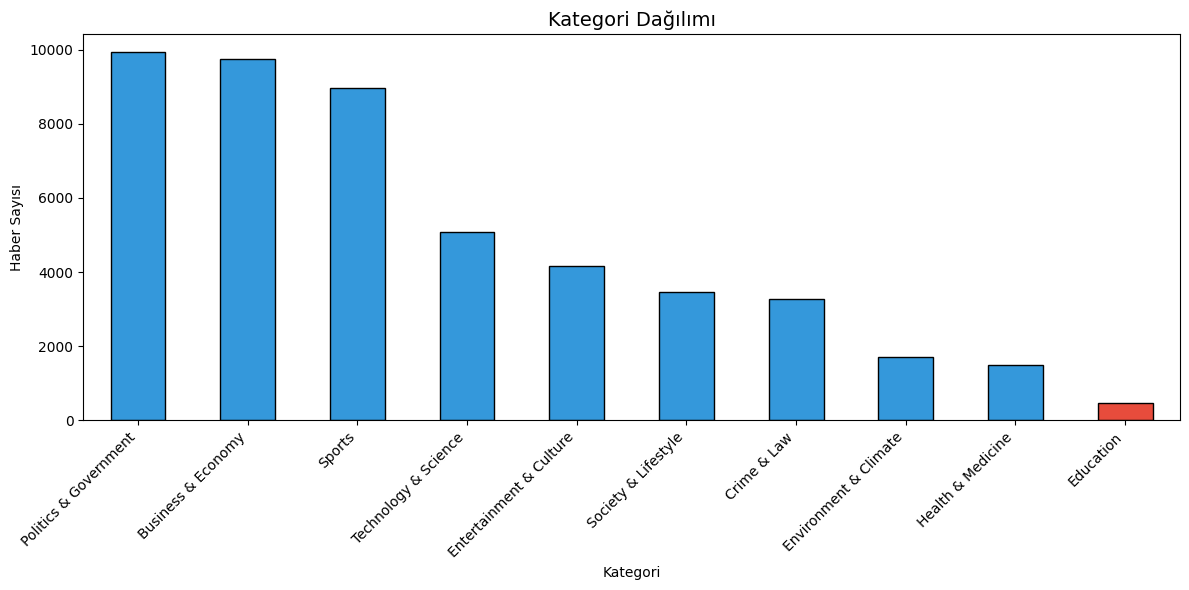

En az örnek: Education → 481 haber
En fazla örnek: Politics & Government → 9930 haber


In [ ]:
plt.figure(figsize=(12, 6))
renkler = ['#e74c3c' if x == df['topic'].value_counts().min()
           else '#3498db' for x in df['topic'].value_counts()]

df['topic'].value_counts().plot(kind='bar', color=renkler, edgecolor='black')
plt.title('Kategori Dağılımı', fontsize=14)
plt.xlabel('Kategori')
plt.ylabel('Haber Sayısı')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

print("En az örnek:", df['topic'].value_counts().idxmin(),
      "→", df['topic'].value_counts().min(), "haber")
print("En fazla örnek:", df['topic'].value_counts().idxmax(),
      "→", df['topic'].value_counts().max(), "haber")

**Veriyi Hazırlama**

In [ ]:
X = df['title']
y = df['topic']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Eğitim seti:", len(X_train), "haber")
print("Test seti:", len(X_test), "haber")

Eğitim seti: 38657 haber
Test seti: 9665 haber


### Test Seti Verileri

In [ ]:
print(y_test.value_counts())

topic
Politics & Government      1986
Business & Economy         1951
Sports                     1791
Technology & Science       1019
Entertainment & Culture     834
Society & Lifestyle         694
Crime & Law                 655
Environment & Climate       342
Health & Medicine           297
Education                    96
Name: count, dtype: int64


### **FEATURE EXTRACTION**

**TF-IDF**

In [ ]:
tfidf = TfidfVectorizer(max_features=10000, stop_words='english')

X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

print("TF-IDF öncesi:", X_train.shape)
print("TF-IDF sonrası:", X_train_tfidf.shape)

TF-IDF öncesi: (38657,)
TF-IDF sonrası: (38657, 10000)


### **Future Selection**

In [ ]:
selector = SelectKBest(chi2, k=5000)

X_train_selected = selector.fit_transform(X_train_tfidf, y_train)
X_test_selected = selector.transform(X_test_tfidf)

print("Feature selection öncesi:", X_train_tfidf.shape)
print("Feature selection sonrası:", X_train_selected.shape)

Feature selection öncesi: (38657, 10000)
Feature selection sonrası: (38657, 5000)


### **LOGISTIC REGRESSION**

In [ ]:
kategoriler = sorted(y.unique())
y_test_bin = label_binarize(y_test, classes=kategoriler)

lr_model = LogisticRegression(max_iter=1000, class_weight='balanced')
lr_model.fit(X_train_selected, y_train)
lr_tahmin = lr_model.predict(X_test_selected)
lr_proba = lr_model.predict_proba(X_test_selected)

lr_sonuc = {
    'Accuracy': accuracy_score(y_test, lr_tahmin),
    'Precision': precision_score(y_test, lr_tahmin, average='macro', zero_division=0),
    'Recall': recall_score(y_test, lr_tahmin, average='macro', zero_division=0),
    'F1 Macro': f1_score(y_test, lr_tahmin, average='macro'),
    'F1 Weighted': f1_score(y_test, lr_tahmin, average='weighted'),
    'Specificity': specificity_score(y_test, lr_tahmin, kategoriler),
    'Cohen Kappa': cohen_kappa_score(y_test, lr_tahmin),
    'ROC AUC': roc_auc_score(y_test_bin, lr_proba, multi_class='ovr', average='macro')
}

print("Logistic Regression Sonuçları:")
print("-" * 35)
for metrik, deger in lr_sonuc.items():
    print(f"{metrik:15}: {deger:.4f}")

Logistic Regression Sonuçları:
-----------------------------------
Accuracy       : 0.7513
Precision      : 0.6756
Recall         : 0.7359
F1 Macro       : 0.6986
F1 Weighted    : 0.7568
Specificity    : 0.9720
Cohen Kappa    : 0.7112
ROC AUC        : 0.9586


**Parametre Optimizasyonu**

In [ ]:
parametreler = {
    'C': [0.01, 0.1, 1, 10, 100],
    'solver': ['lbfgs', 'saga'],
    'max_iter': [1000]
}

grid_search_lr = GridSearchCV(
    LogisticRegression(class_weight='balanced'),
    parametreler,
    cv=3,
    scoring='f1_macro',
    n_jobs=-1,
    verbose=1
)

grid_search_lr.fit(X_train_selected, y_train)

print(f"En iyi parametreler: {grid_search_lr.best_params_}")
print(f"En iyi F1 Macro: {grid_search_lr.best_score_:.4f}")

Fitting 3 folds for each of 10 candidates, totalling 30 fits
En iyi parametreler: {'C': 10, 'max_iter': 1000, 'solver': 'lbfgs'}
En iyi F1 Macro: 0.7004


In [ ]:
lr_model = LogisticRegression(C=10, solver='lbfgs', max_iter=1000, class_weight='balanced')
lr_model.fit(X_train_selected, y_train)
lr_tahmin = lr_model.predict(X_test_selected)
lr_proba = lr_model.predict_proba(X_test_selected)

lr_sonuc = {
    'Accuracy': accuracy_score(y_test, lr_tahmin),
    'Precision': precision_score(y_test, lr_tahmin, average='macro', zero_division=0),
    'Recall': recall_score(y_test, lr_tahmin, average='macro', zero_division=0),
    'F1 Macro': f1_score(y_test, lr_tahmin, average='macro'),
    'F1 Weighted': f1_score(y_test, lr_tahmin, average='weighted'),
    'Specificity': specificity_score(y_test, lr_tahmin, kategoriler),
    'Cohen Kappa': cohen_kappa_score(y_test, lr_tahmin),
    'ROC AUC': roc_auc_score(y_test_bin, lr_proba, multi_class='ovr', average='macro')
}

print("Logistic Regression (optimized) Sonuçları:")
print("-" * 40)
for metrik, deger in lr_sonuc.items():
    print(f"{metrik:15}: {deger:.4f}")

Logistic Regression (optimized) Sonuçları:
----------------------------------------
Accuracy       : 0.7583
Precision      : 0.6935
Recall         : 0.7280
F1 Macro       : 0.7080
F1 Weighted    : 0.7627
Specificity    : 0.9727
Cohen Kappa    : 0.7184
ROC AUC        : 0.9569


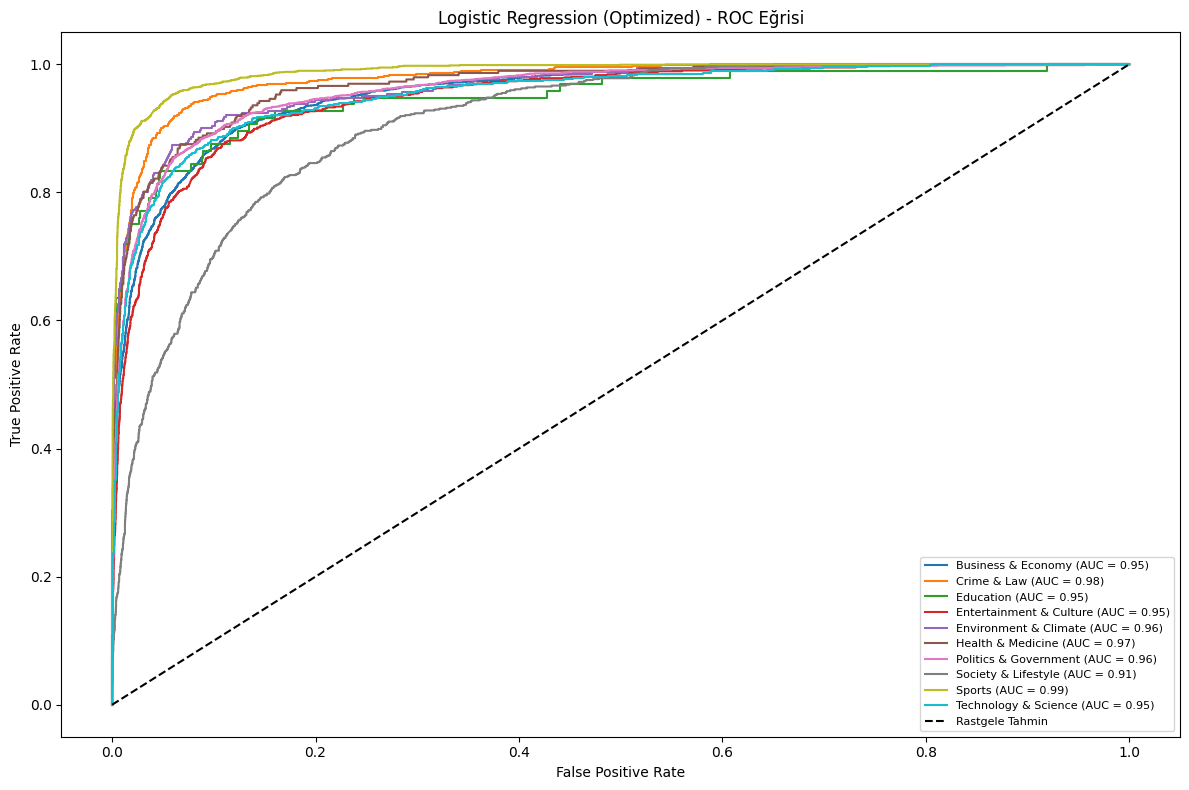

In [ ]:
plt.figure(figsize=(12, 8))

for i, kategori in enumerate(kategoriler):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], lr_proba[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f'{kategori} (AUC = {roc_auc:.2f})')

plt.plot([0, 1], [0, 1], 'k--', label='Rastgele Tahmin')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Logistic Regression (Optimized) - ROC Eğrisi')
plt.legend(loc='lower right', fontsize=8)
plt.tight_layout()
plt.show()

1.0 → Mükemmel, her kategoriyi %100 doğru ayırt ediyor

0.9 - 1.0 → Çok iyi

0.7 - 0.9 → İyi

0.5 → Berbat, rastgele tahmin kadar

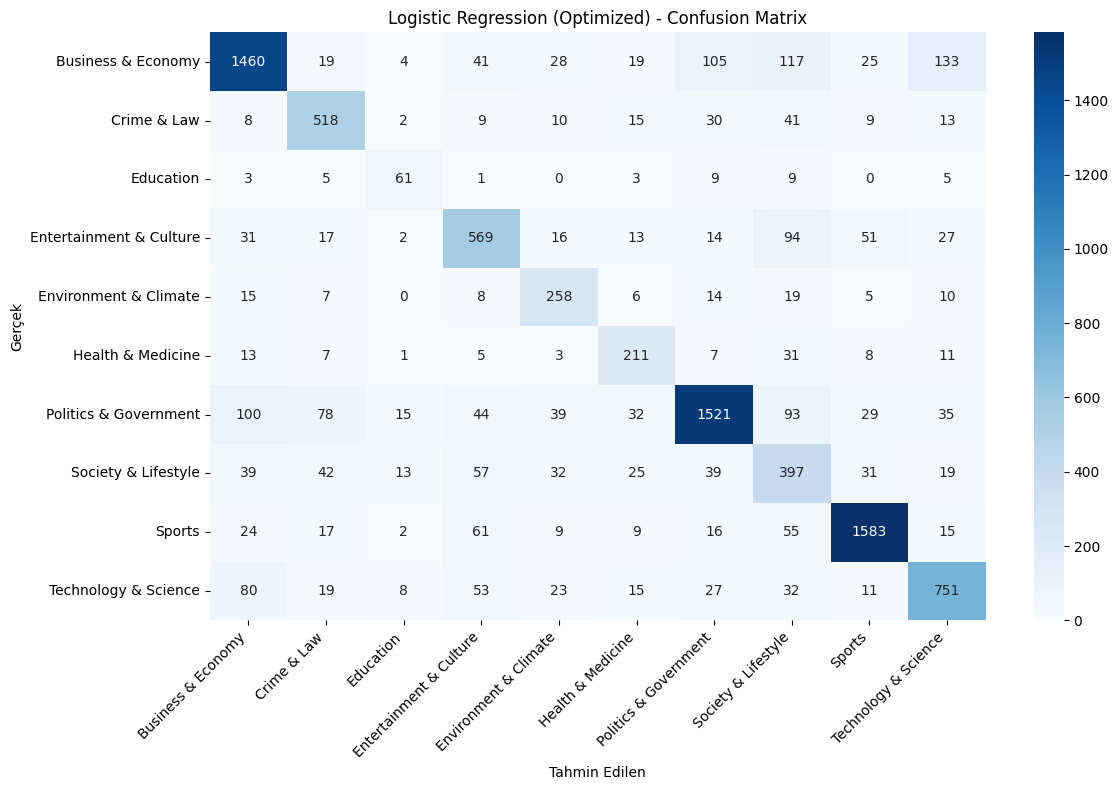

In [ ]:
plt.figure(figsize=(12, 8))
cm = confusion_matrix(y_test, lr_tahmin, labels=kategoriler)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=kategoriler,
            yticklabels=kategoriler)
plt.title('Logistic Regression (Optimized) - Confusion Matrix')
plt.xlabel('Tahmin Edilen')
plt.ylabel('Gerçek')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

### **NAIVE BAYES**

In [ ]:
parametreler = {
    'alpha': [0.01, 0.1, 0.5, 1.0, 2.0, 5.0]
}

grid_search_nb = GridSearchCV(
    MultinomialNB(),
    parametreler,
    cv=3,
    scoring='f1_macro',
    n_jobs=-1,
    verbose=1
)

grid_search_nb.fit(X_train_selected, y_train)

print(f"En iyi parametreler: {grid_search_nb.best_params_}")
print(f"En iyi F1 Macro: {grid_search_nb.best_score_:.4f}")

Fitting 3 folds for each of 6 candidates, totalling 18 fits
En iyi parametreler: {'alpha': 0.1}
En iyi F1 Macro: 0.6694


In [ ]:
nb_model = MultinomialNB(alpha=0.1)
nb_model.fit(X_train_selected, y_train)
nb_tahmin = nb_model.predict(X_test_selected)
nb_proba = nb_model.predict_proba(X_test_selected)

nb_sonuc = {
    'Accuracy': accuracy_score(y_test, nb_tahmin),
    'Precision': precision_score(y_test, nb_tahmin, average='macro', zero_division=0),
    'Recall': recall_score(y_test, nb_tahmin, average='macro', zero_division=0),
    'F1 Macro': f1_score(y_test, nb_tahmin, average='macro'),
    'F1 Weighted': f1_score(y_test, nb_tahmin, average='weighted'),
    'Specificity': specificity_score(y_test, nb_tahmin, kategoriler),
    'Cohen Kappa': cohen_kappa_score(y_test, nb_tahmin),
    'ROC AUC': roc_auc_score(y_test_bin, nb_proba, multi_class='ovr', average='macro')
}

print("Naive Bayes (Optimized) Sonuçları:")
print("-" * 40)
for metrik, deger in nb_sonuc.items():
    print(f"{metrik:15}: {deger:.4f}")

Naive Bayes (Optimized) Sonuçları:
----------------------------------------
Accuracy       : 0.7483
Precision      : 0.7426
Recall         : 0.6192
F1 Macro       : 0.6512
F1 Weighted    : 0.7403
Specificity    : 0.9700
Cohen Kappa    : 0.7008
ROC AUC        : 0.9605


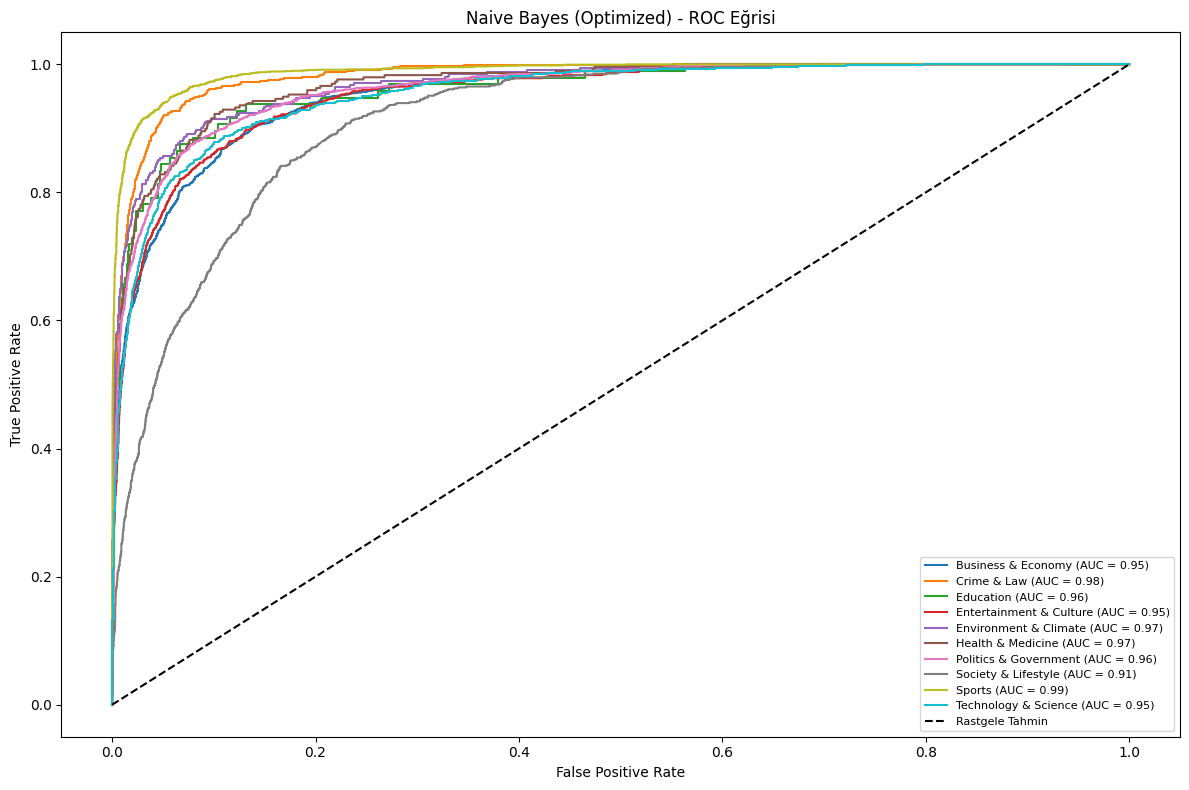

In [ ]:
plt.figure(figsize=(12, 8))

for i, kategori in enumerate(kategoriler):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], nb_proba[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f'{kategori} (AUC = {roc_auc:.2f})')

plt.plot([0, 1], [0, 1], 'k--', label='Rastgele Tahmin')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Naive Bayes (Optimized) - ROC Eğrisi')
plt.legend(loc='lower right', fontsize=8)
plt.tight_layout()
plt.show()

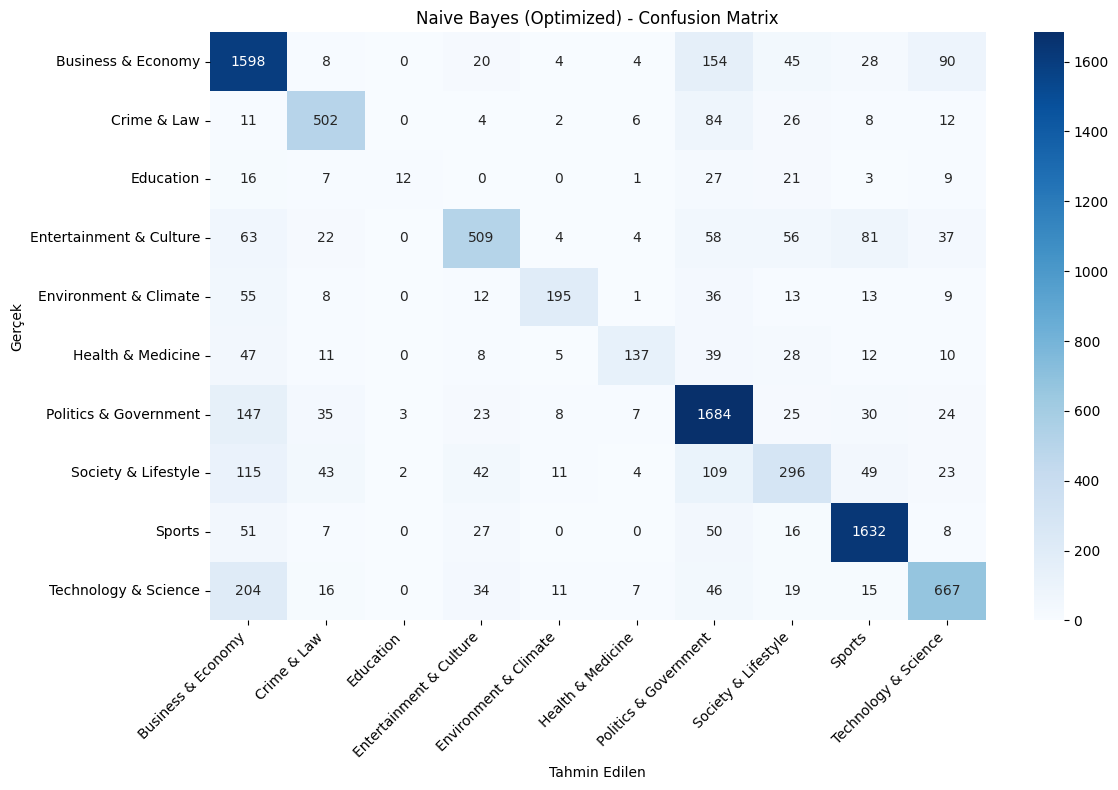

In [ ]:
plt.figure(figsize=(12, 8))
cm = confusion_matrix(y_test, nb_tahmin, labels=kategoriler)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=kategoriler,
            yticklabels=kategoriler)
plt.title('Naive Bayes (Optimized) - Confusion Matrix')
plt.xlabel('Tahmin Edilen')
plt.ylabel('Gerçek')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

### **LINEAR SVC**

In [ ]:
parametreler = {
    'C': [0.01, 0.1, 1, 10, 100],
    'max_iter': [1000, 2000]
}

grid_search_svc = GridSearchCV(
    LinearSVC(class_weight='balanced'),
    parametreler,
    cv=3,
    scoring='f1_macro',
    n_jobs=-1,
    verbose=1
)

grid_search_svc.fit(X_train_selected, y_train)

print(f"En iyi parametreler: {grid_search_svc.best_params_}")
print(f"En iyi F1 Macro: {grid_search_svc.best_score_:.4f}")

Fitting 3 folds for each of 10 candidates, totalling 30 fits
En iyi parametreler: {'C': 1, 'max_iter': 1000}
En iyi F1 Macro: 0.7054


In [ ]:
svc_model = LinearSVC(C=1, max_iter=1000, class_weight='balanced')
svc_model.fit(X_train_selected, y_train)
svc_tahmin = svc_model.predict(X_test_selected)

svc_sonuc = {
    'Accuracy': accuracy_score(y_test, svc_tahmin),
    'Precision': precision_score(y_test, svc_tahmin, average='macro', zero_division=0),
    'Recall': recall_score(y_test, svc_tahmin, average='macro', zero_division=0),
    'F1 Macro': f1_score(y_test, svc_tahmin, average='macro'),
    'F1 Weighted': f1_score(y_test, svc_tahmin, average='weighted'),
    'Specificity': specificity_score(y_test, svc_tahmin, kategoriler),
    'Cohen Kappa': cohen_kappa_score(y_test, svc_tahmin),
    'ROC AUC': None
}

print("Linear SVC (Optimized) Sonuçları:")
print("-" * 40)
for metrik, deger in svc_sonuc.items():
    if deger is not None:
        print(f"{metrik:15}: {deger:.4f}")
    else:
        print(f"{metrik:15}: N/A (LinearSVC olasılık üretmez)")

Linear SVC (Optimized) Sonuçları:
----------------------------------------
Accuracy       : 0.7661
Precision      : 0.6951
Recall         : 0.7237
F1 Macro       : 0.7078
F1 Weighted    : 0.7676
Specificity    : 0.9733
Cohen Kappa    : 0.7265
ROC AUC        : N/A (LinearSVC olasılık üretmez)


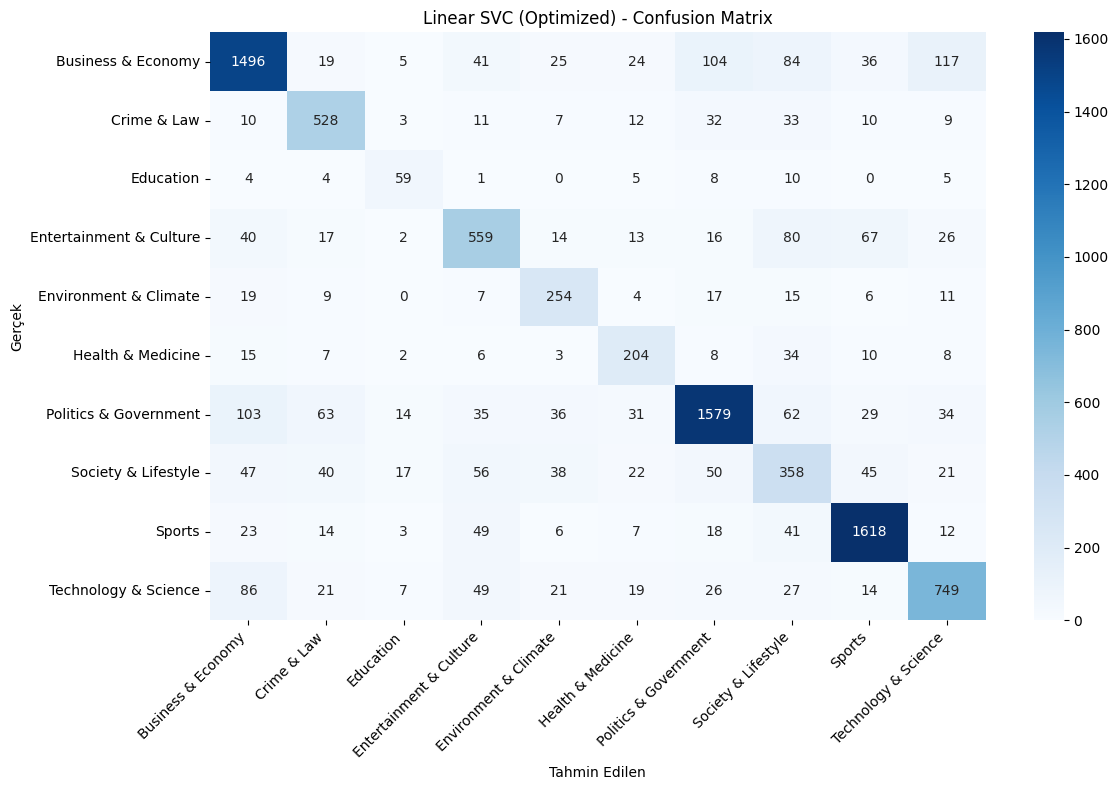

In [ ]:
plt.figure(figsize=(12, 8))
cm = confusion_matrix(y_test, svc_tahmin, labels=kategoriler)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=kategoriler,
            yticklabels=kategoriler)
plt.title('Linear SVC (Optimized) - Confusion Matrix')
plt.xlabel('Tahmin Edilen')
plt.ylabel('Gerçek')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

### **RANDOM FOREST**

In [ ]:
parametreler = {
    'n_estimators': [100, 200],
    'max_depth': [10, 20, None],
    'min_samples_split': [2, 5]
}

grid_search_rf = GridSearchCV(
    RandomForestClassifier(class_weight='balanced', random_state=42),
    parametreler,
    cv=3,
    scoring='f1_macro',
    n_jobs=-1,
    verbose=1
)

grid_search_rf.fit(X_train_selected, y_train)

print(f"En iyi parametreler: {grid_search_rf.best_params_}")
print(f"En iyi F1 Macro: {grid_search_rf.best_score_:.4f}")

Fitting 3 folds for each of 12 candidates, totalling 36 fits
En iyi parametreler: {'max_depth': None, 'min_samples_split': 5, 'n_estimators': 200}
En iyi F1 Macro: 0.6452


In [ ]:
rf_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=None,
    min_samples_split=5,
    class_weight='balanced',
    random_state=42
)
rf_model.fit(X_train_selected, y_train)
rf_tahmin = rf_model.predict(X_test_selected)
rf_proba = rf_model.predict_proba(X_test_selected)

rf_sonuc = {
    'Accuracy': accuracy_score(y_test, rf_tahmin),
    'Precision': precision_score(y_test, rf_tahmin, average='macro', zero_division=0),
    'Recall': recall_score(y_test, rf_tahmin, average='macro', zero_division=0),
    'F1 Macro': f1_score(y_test, rf_tahmin, average='macro'),
    'F1 Weighted': f1_score(y_test, rf_tahmin, average='weighted'),
    'Specificity': specificity_score(y_test, rf_tahmin, kategoriler),
    'Cohen Kappa': cohen_kappa_score(y_test, rf_tahmin),
    'ROC AUC': roc_auc_score(y_test_bin, rf_proba, multi_class='ovr', average='macro')
}

print("Random Forest (Optimized) Sonuçları:")
print("-" * 40)
for metrik, deger in rf_sonuc.items():
    print(f"{metrik:15}: {deger:.4f}")

Random Forest (Optimized) Sonuçları:
----------------------------------------
Accuracy       : 0.7033
Precision      : 0.6425
Recall         : 0.6553
F1 Macro       : 0.6473
F1 Weighted    : 0.7031
Specificity    : 0.9658
Cohen Kappa    : 0.6523
ROC AUC        : 0.9391


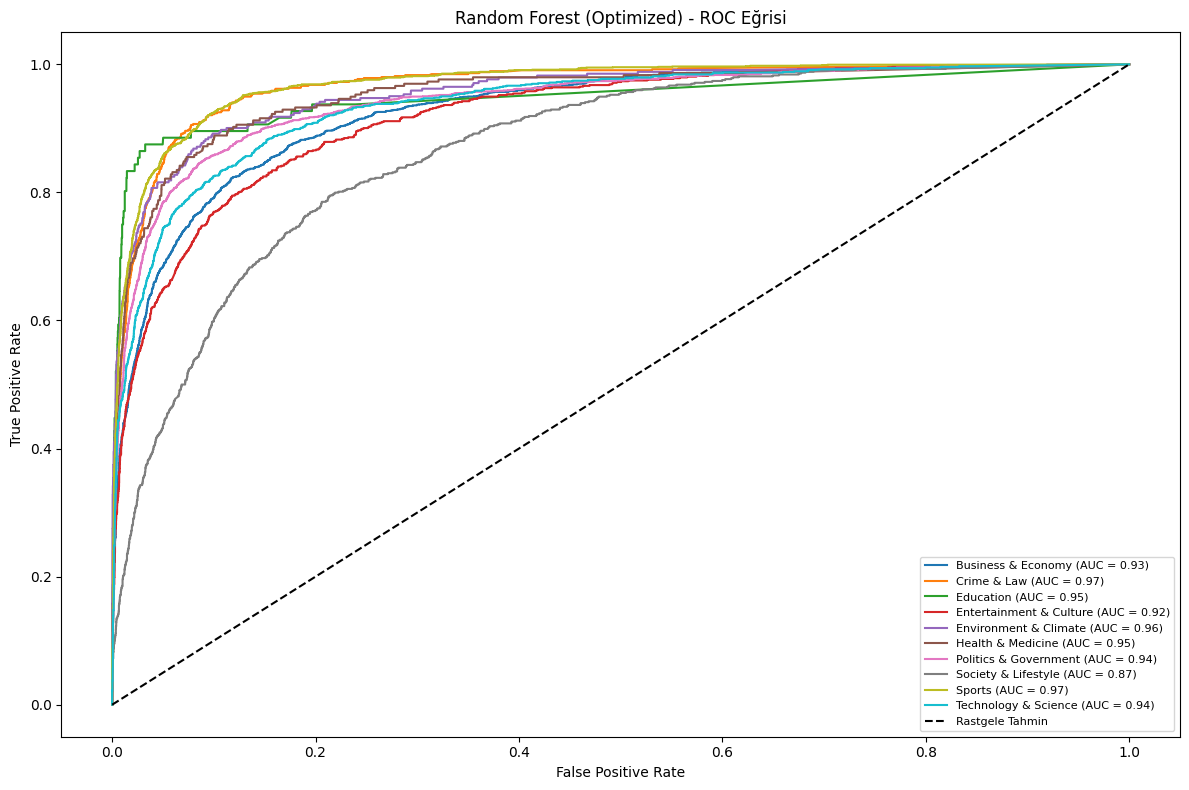

In [ ]:
plt.figure(figsize=(12, 8))

for i, kategori in enumerate(kategoriler):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], rf_proba[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f'{kategori} (AUC = {roc_auc:.2f})')

plt.plot([0, 1], [0, 1], 'k--', label='Rastgele Tahmin')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Random Forest (Optimized) - ROC Eğrisi')
plt.legend(loc='lower right', fontsize=8)
plt.tight_layout()
plt.show()

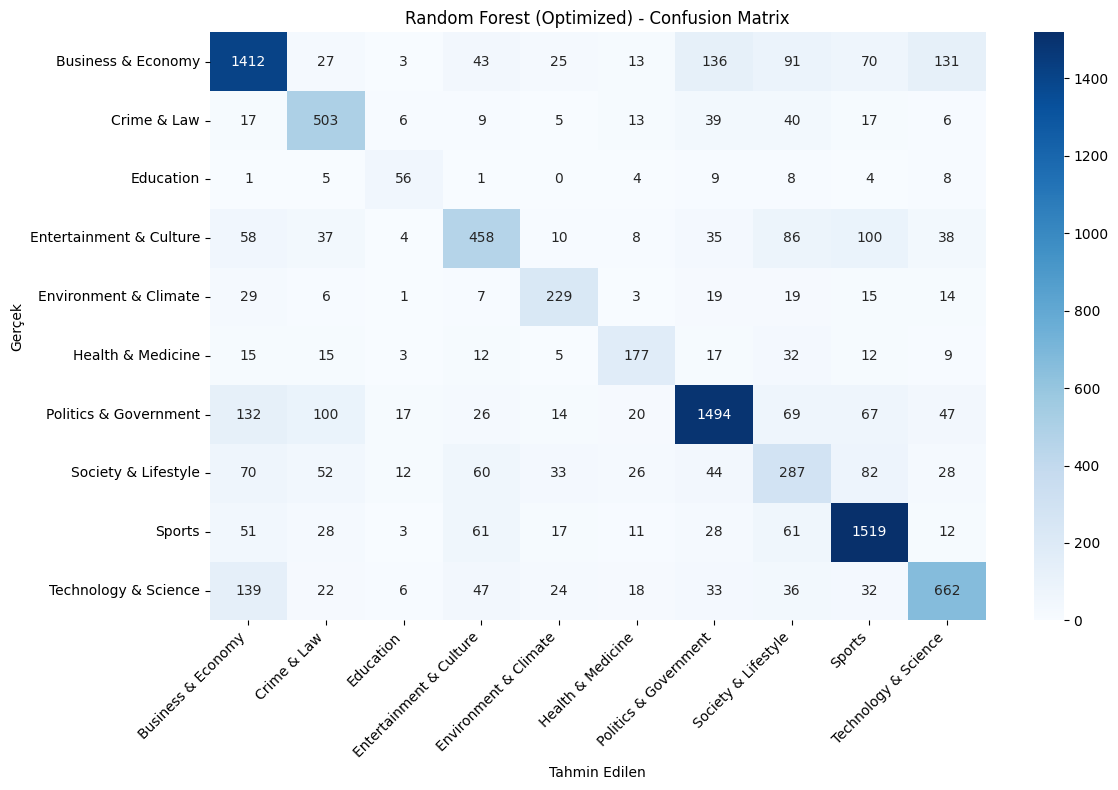

In [ ]:
plt.figure(figsize=(12, 8))
cm = confusion_matrix(y_test, rf_tahmin, labels=kategoriler)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=kategoriler,
            yticklabels=kategoriler)
plt.title('Random Forest (Optimized) - Confusion Matrix')
plt.xlabel('Tahmin Edilen')
plt.ylabel('Gerçek')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

### **KNN - K NEAREST NEIGHBOURS**

**Normalizasyon**

In [ ]:
X_train_normalized = normalize(X_train_selected)
X_test_normalized = normalize(X_test_selected)

In [ ]:
parametreler = {
    'n_neighbors': [10, 15, 20, 25, 30],
    'metric': ['cosine', 'euclidean']
}

grid_search_knn = GridSearchCV(
    KNeighborsClassifier(),
    parametreler,
    cv=3,
    scoring='f1_macro',
    n_jobs=-1,
    verbose=1
)

grid_search_knn.fit(X_train_normalized, y_train)

print(f"En iyi parametreler: {grid_search_knn.best_params_}")
print(f"En iyi F1 Macro: {grid_search_knn.best_score_:.4f}")

Fitting 3 folds for each of 10 candidates, totalling 30 fits
En iyi parametreler: {'metric': 'cosine', 'n_neighbors': 15}
En iyi F1 Macro: 0.6241


In [ ]:
knn_model = KNeighborsClassifier(n_neighbors=15, metric='cosine')
knn_model.fit(X_train_normalized, y_train)
knn_tahmin = knn_model.predict(X_test_normalized)
knn_proba = knn_model.predict_proba(X_test_normalized)

knn_sonuc = {
    'Accuracy': accuracy_score(y_test, knn_tahmin),
    'Precision': precision_score(y_test, knn_tahmin, average='macro', zero_division=0),
    'Recall': recall_score(y_test, knn_tahmin, average='macro', zero_division=0),
    'F1 Macro': f1_score(y_test, knn_tahmin, average='macro'),
    'F1 Weighted': f1_score(y_test, knn_tahmin, average='weighted'),
    'Specificity': specificity_score(y_test, knn_tahmin, kategoriler),
    'Cohen Kappa': cohen_kappa_score(y_test, knn_tahmin),
    'ROC AUC': roc_auc_score(y_test_bin, knn_proba, multi_class='ovr', average='macro')
}

print("KNN (Optimized) Sonuçları:")
print("-" * 40)
for metrik, deger in knn_sonuc.items():
    print(f"{metrik:15}: {deger:.4f}")

KNN (Optimized) Sonuçları:
----------------------------------------
Accuracy       : 0.7284
Precision      : 0.7055
Recall         : 0.6034
F1 Macro       : 0.6351
F1 Weighted    : 0.7184
Specificity    : 0.9678
Cohen Kappa    : 0.6772
ROC AUC        : 0.9259


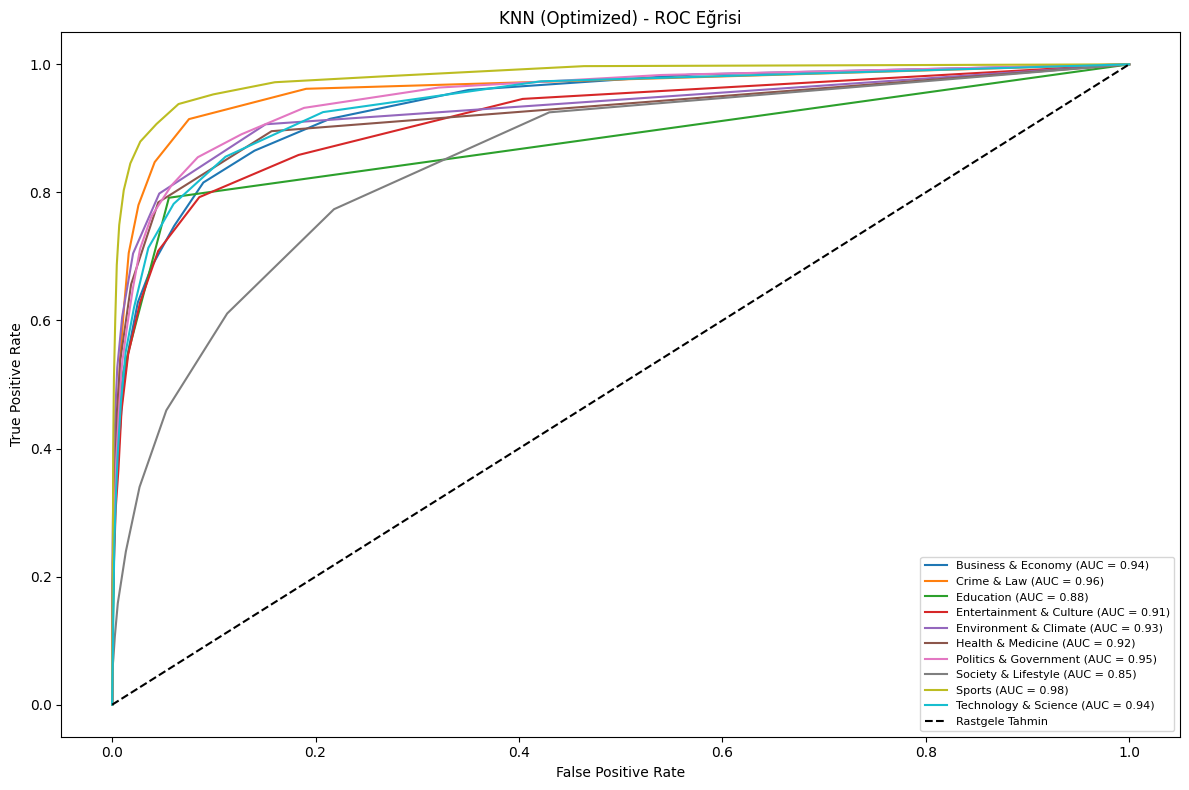

In [ ]:
plt.figure(figsize=(12, 8))

for i, kategori in enumerate(kategoriler):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], knn_proba[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f'{kategori} (AUC = {roc_auc:.2f})')

plt.plot([0, 1], [0, 1], 'k--', label='Rastgele Tahmin')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('KNN (Optimized) - ROC Eğrisi')
plt.legend(loc='lower right', fontsize=8)
plt.tight_layout()
plt.show()

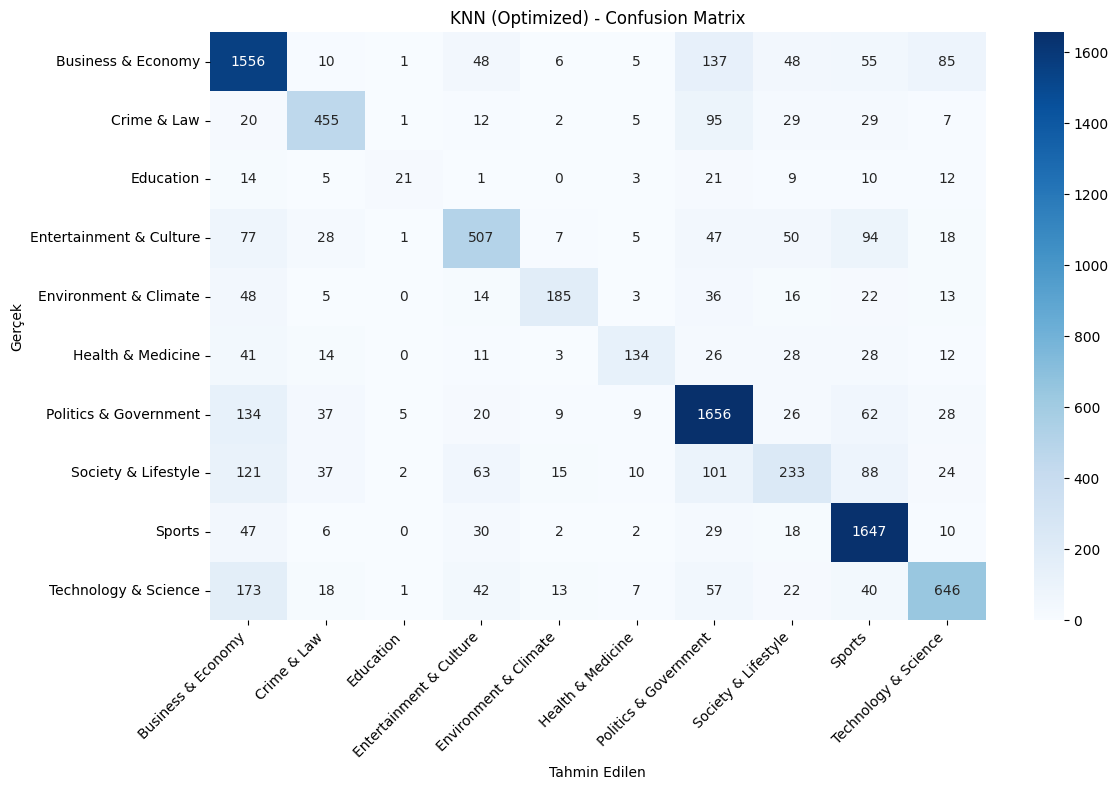

In [ ]:
plt.figure(figsize=(12, 8))
cm = confusion_matrix(y_test, knn_tahmin, labels=kategoriler)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=kategoriler,
            yticklabels=kategoriler)
plt.title('KNN (Optimized) - Confusion Matrix')
plt.xlabel('Tahmin Edilen')
plt.ylabel('Gerçek')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

### **DECISION TREE**

In [ ]:
parametreler = {
    'max_depth': [10, 20, 30, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

grid_search_dt = GridSearchCV(
    DecisionTreeClassifier(class_weight='balanced', random_state=42),
    parametreler,
    cv=3,
    scoring='f1_macro',
    n_jobs=-1,
    verbose=1
)

grid_search_dt.fit(X_train_selected, y_train)

print(f"En iyi parametreler: {grid_search_dt.best_params_}")
print(f"En iyi F1 Macro: {grid_search_dt.best_score_:.4f}")

Fitting 3 folds for each of 36 candidates, totalling 108 fits
En iyi parametreler: {'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 2}
En iyi F1 Macro: 0.5585


In [ ]:
dt_model = DecisionTreeClassifier(
    max_depth=None,
    min_samples_leaf=1,
    min_samples_split=2,
    class_weight='balanced',
    random_state=42
)
dt_model.fit(X_train_selected, y_train)
dt_tahmin = dt_model.predict(X_test_selected)
dt_proba = dt_model.predict_proba(X_test_selected)

dt_sonuc = {
    'Accuracy': accuracy_score(y_test, dt_tahmin),
    'Precision': precision_score(y_test, dt_tahmin, average='macro', zero_division=0),
    'Recall': recall_score(y_test, dt_tahmin, average='macro', zero_division=0),
    'F1 Macro': f1_score(y_test, dt_tahmin, average='macro'),
    'F1 Weighted': f1_score(y_test, dt_tahmin, average='weighted'),
    'Specificity': specificity_score(y_test, dt_tahmin, kategoriler),
    'Cohen Kappa': cohen_kappa_score(y_test, dt_tahmin),
    'ROC AUC': roc_auc_score(y_test_bin, dt_proba, multi_class='ovr', average='macro')
}

print("Decision Tree (Optimized) Sonuçları:")
print("-" * 40)
for metrik, deger in dt_sonuc.items():
    print(f"{metrik:15}: {deger:.4f}")

Decision Tree (Optimized) Sonuçları:
----------------------------------------
Accuracy       : 0.6210
Precision      : 0.5609
Recall         : 0.5835
F1 Macro       : 0.5700
F1 Weighted    : 0.6251
Specificity    : 0.9564
Cohen Kappa    : 0.5574
ROC AUC        : 0.7746


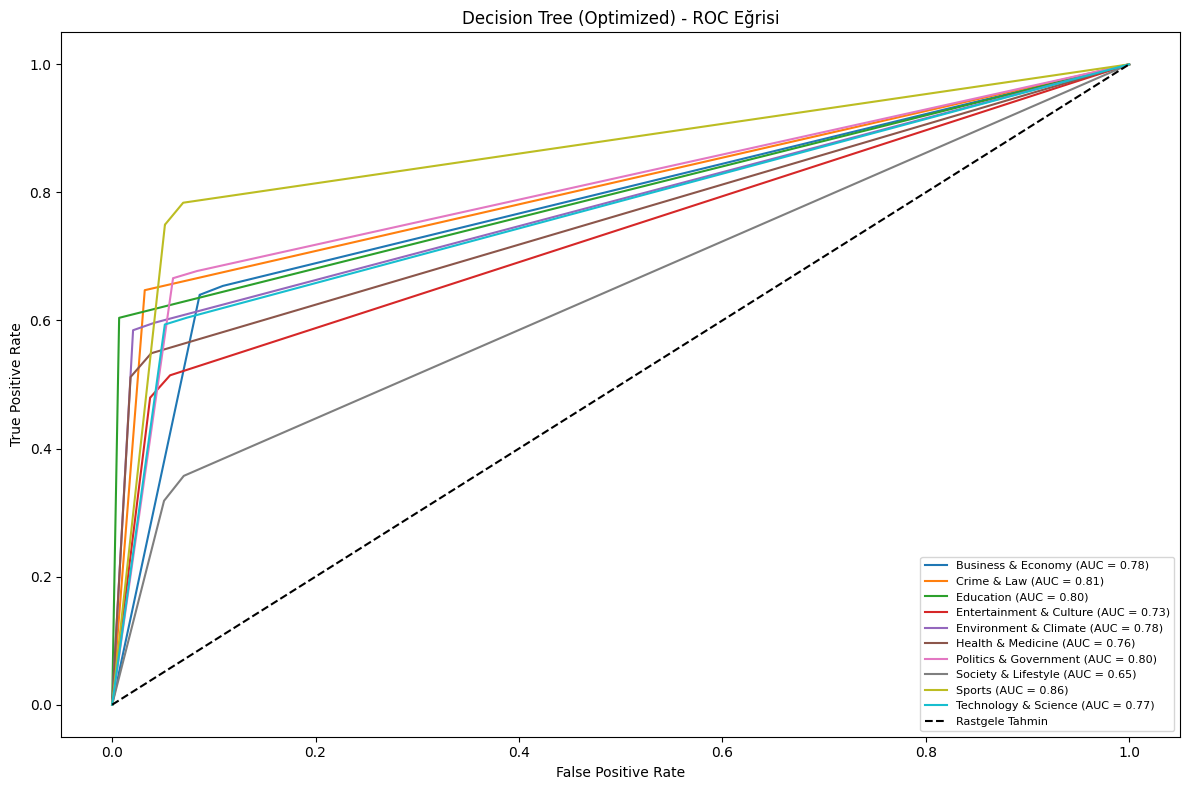

In [ ]:
plt.figure(figsize=(12, 8))

for i, kategori in enumerate(kategoriler):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], dt_proba[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f'{kategori} (AUC = {roc_auc:.2f})')

plt.plot([0, 1], [0, 1], 'k--', label='Rastgele Tahmin')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Decision Tree (Optimized) - ROC Eğrisi')
plt.legend(loc='lower right', fontsize=8)
plt.tight_layout()
plt.show()

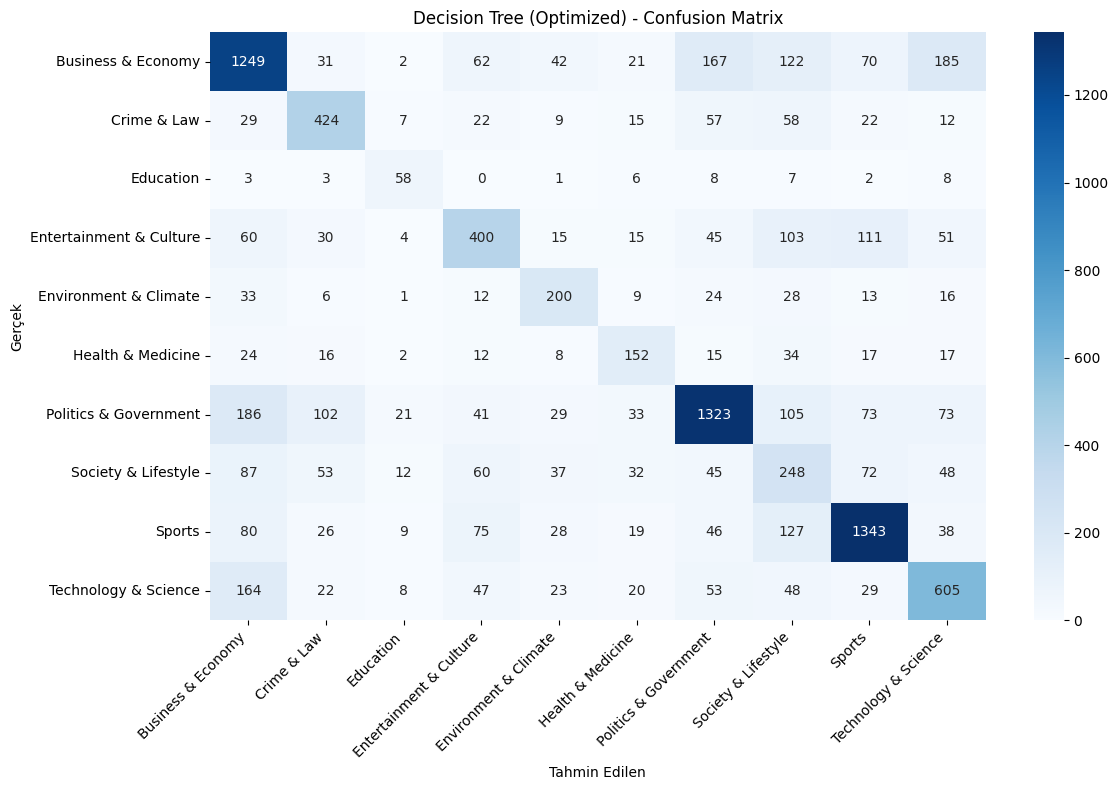

In [ ]:
plt.figure(figsize=(12, 8))
cm = confusion_matrix(y_test, dt_tahmin, labels=kategoriler)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=kategoriler,
            yticklabels=kategoriler)
plt.title('Decision Tree (Optimized) - Confusion Matrix')
plt.xlabel('Tahmin Edilen')
plt.ylabel('Gerçek')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

### **XGBOOST**

XGBoost - Önce LabelEncoder

In [ ]:
le = LabelEncoder()
y_train_encoded = le.fit_transform(y_train)
y_test_encoded = le.transform(y_test)

print("Kategoriler ve karşılık gelen sayılar:")
for i, kategori in enumerate(le.classes_):
    print(f"{i}: {kategori}")

Kategoriler ve karşılık gelen sayılar:
0: Business & Economy
1: Crime & Law
2: Education
3: Entertainment & Culture
4: Environment & Climate
5: Health & Medicine
6: Politics & Government
7: Society & Lifestyle
8: Sports
9: Technology & Science


In [ ]:
parametreler = {
    'n_estimators': [100, 200],
    'max_depth': [3, 6, 9],
    'learning_rate': [0.01, 0.1, 0.3],
    'subsample': [0.8, 1.0]
}

grid_search_xgb = GridSearchCV(
    XGBClassifier(random_state=42, eval_metric='mlogloss'),
    parametreler,
    cv=3,
    scoring='f1_macro',
    n_jobs=-1,
    verbose=1
)

grid_search_xgb.fit(X_train_selected, y_train_encoded)

print(f"En iyi parametreler: {grid_search_xgb.best_params_}")
print(f"En iyi F1 Macro: {grid_search_xgb.best_score_:.4f}")

Fitting 3 folds for each of 36 candidates, totalling 108 fits
En iyi parametreler: {'learning_rate': 0.3, 'max_depth': 9, 'n_estimators': 200, 'subsample': 1.0}
En iyi F1 Macro: 0.6583


In [ ]:
xgb_model = XGBClassifier(
    learning_rate=0.3,
    max_depth=9,
    n_estimators=200,
    subsample=1.0,
    random_state=42,
    eval_metric='mlogloss'
)
xgb_model.fit(X_train_selected, y_train_encoded)
xgb_tahmin_encoded = xgb_model.predict(X_test_selected)
xgb_tahmin = le.inverse_transform(xgb_tahmin_encoded)
xgb_proba = xgb_model.predict_proba(X_test_selected)

xgb_sonuc = {
    'Accuracy': accuracy_score(y_test, xgb_tahmin),
    'Precision': precision_score(y_test, xgb_tahmin, average='macro', zero_division=0),
    'Recall': recall_score(y_test, xgb_tahmin, average='macro', zero_division=0),
    'F1 Macro': f1_score(y_test, xgb_tahmin, average='macro'),
    'F1 Weighted': f1_score(y_test, xgb_tahmin, average='weighted'),
    'Specificity': specificity_score(y_test, xgb_tahmin, kategoriler),
    'Cohen Kappa': cohen_kappa_score(y_test, xgb_tahmin),
    'ROC AUC': roc_auc_score(y_test_bin, xgb_proba, multi_class='ovr', average='macro')
}

print("XGBoost (Optimized) Sonuçları:")
print("-" * 40)
for metrik, deger in xgb_sonuc.items():
    print(f"{metrik:15}: {deger:.4f}")

XGBoost (Optimized) Sonuçları:
----------------------------------------
Accuracy       : 0.7363
Precision      : 0.6946
Recall         : 0.6495
F1 Macro       : 0.6679
F1 Weighted    : 0.7311
Specificity    : 0.9690
Cohen Kappa    : 0.6883
ROC AUC        : 0.9445


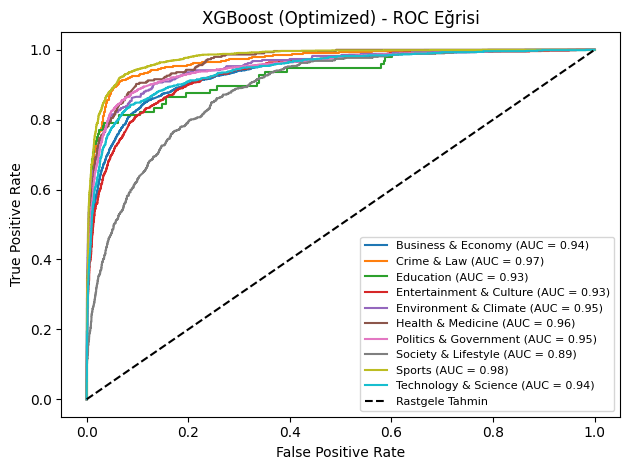

In [ ]:
for i, kategori in enumerate(kategoriler):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], xgb_proba[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f'{kategori} (AUC = {roc_auc:.2f})')

plt.plot([0, 1], [0, 1], 'k--', label='Rastgele Tahmin')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('XGBoost (Optimized) - ROC Eğrisi')
plt.legend(loc='lower right', fontsize=8)
plt.tight_layout()
plt.show()

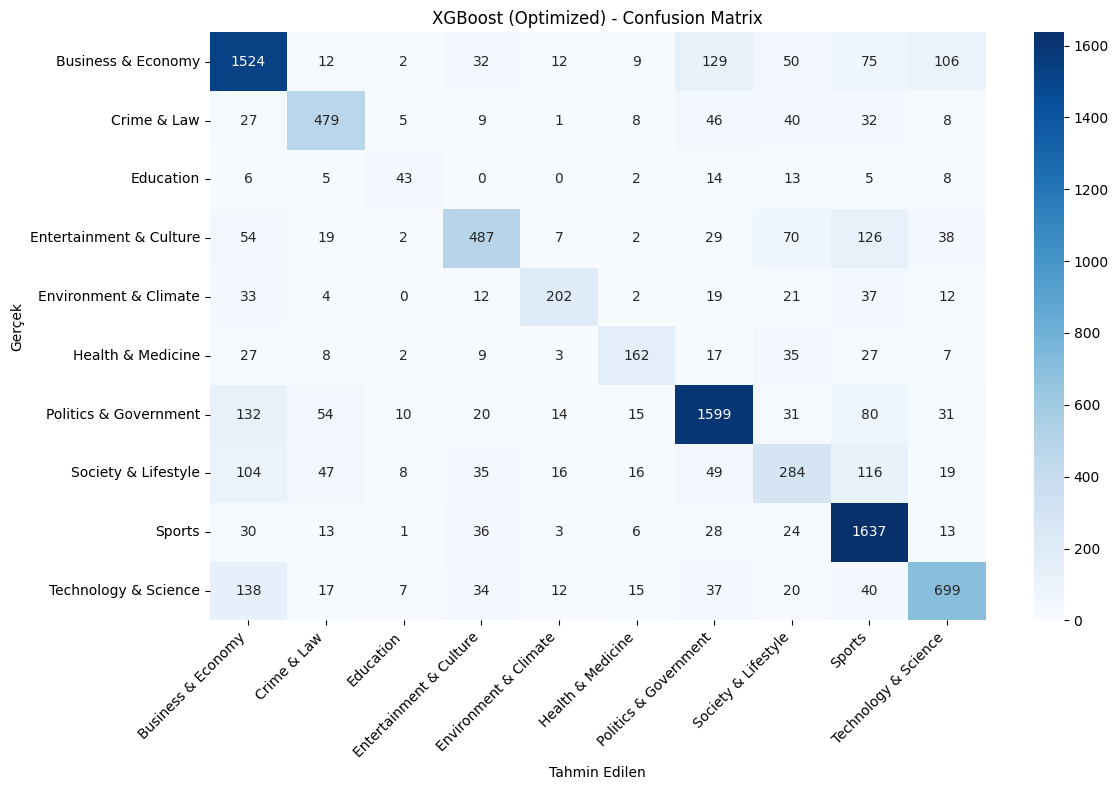

In [ ]:
plt.figure(figsize=(12, 8))
cm = confusion_matrix(y_test, xgb_tahmin, labels=kategoriler)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=kategoriler,
            yticklabels=kategoriler)
plt.title('XGBoost (Optimized) - Confusion Matrix')
plt.xlabel('Tahmin Edilen')
plt.ylabel('Gerçek')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

### **Karşılaştırma**

In [ ]:
# Tüm sonuçları bir araya getir
tum_sonuclar = {
    'Logistic Regression': lr_sonuc,
    'Naive Bayes': nb_sonuc,
    'Linear SVC': svc_sonuc,
    'Random Forest': rf_sonuc,
    'KNN': knn_sonuc,
    'Decision Tree': dt_sonuc,
    'XGBoost': xgb_sonuc
}

# Tablo oluştur
sonuc_df = pd.DataFrame(tum_sonuclar).T
sonuc_df = sonuc_df.drop(columns=['ROC AUC']).astype(float)

# ROC AUC'u ayrı ekle (LinearSVC None)
roc_aucs = {
    'Logistic Regression': lr_sonuc['ROC AUC'],
    'Naive Bayes': nb_sonuc['ROC AUC'],
    'Linear SVC': None,
    'Random Forest': rf_sonuc['ROC AUC'],
    'KNN': knn_sonuc['ROC AUC'],
    'Decision Tree': dt_sonuc['ROC AUC'],
    'XGBoost': xgb_sonuc['ROC AUC']
}
sonuc_df['ROC AUC'] = roc_aucs.values()

print("=" * 80)
print("TÜM MODELLERİN KARŞILAŞTIRMASI")
print("=" * 80)
print(sonuc_df.to_string())

TÜM MODELLERİN KARŞILAŞTIRMASI
                     Accuracy  Precision    Recall  F1 Macro  F1 Weighted  Specificity  Cohen Kappa   ROC AUC
Logistic Regression  0.751267   0.675569  0.735886  0.698630     0.756788     0.972049     0.711153  0.958571
Naive Bayes          0.748267   0.742562  0.619248  0.651195     0.740323     0.970012     0.700834  0.960535
Linear SVC           0.766063   0.695130  0.723665  0.707847     0.767565     0.973333     0.726538       NaN
Random Forest        0.703259   0.642507  0.655331  0.647344     0.703052     0.965799     0.652276  0.939108
KNN                  0.728401   0.705478  0.603410  0.635067     0.718410     0.967751     0.677192  0.925874
Decision Tree        0.621004   0.560901  0.583497  0.569981     0.625105     0.956436     0.557437  0.774620
XGBoost              0.736265   0.694554  0.649472  0.667895     0.731092     0.969024     0.688275  0.944484


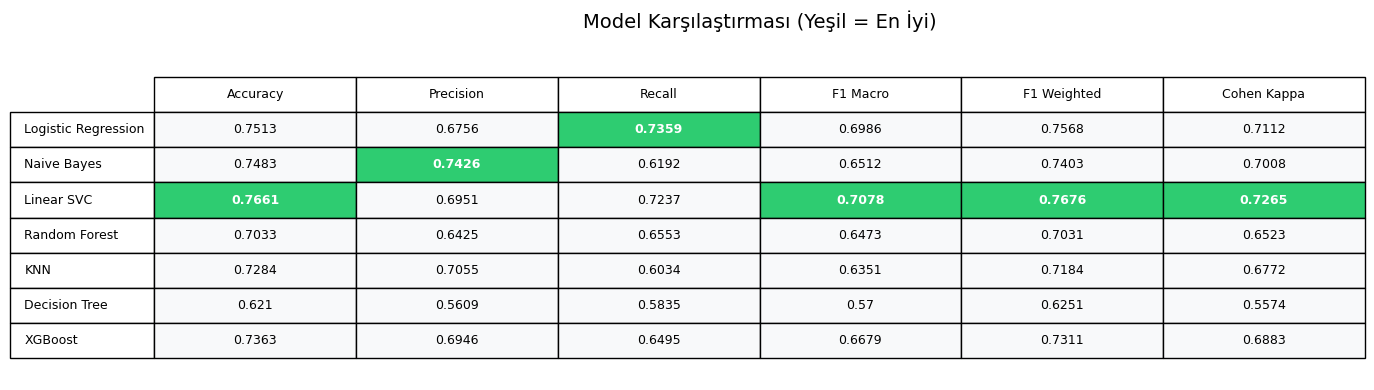

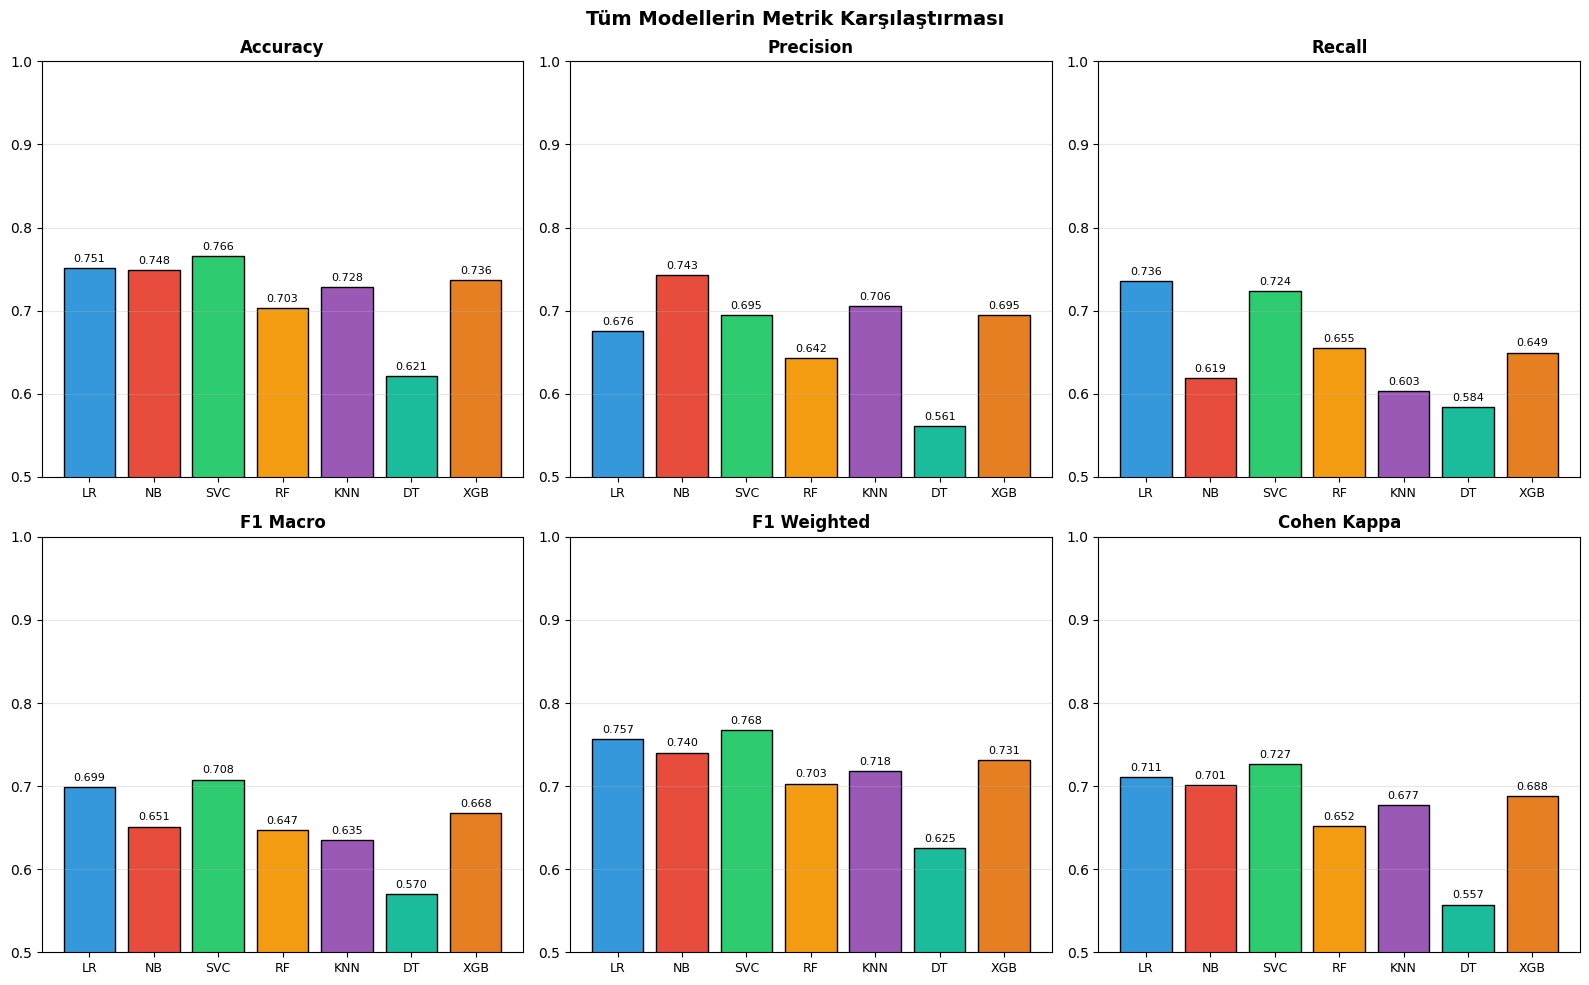

In [ ]:
# Renkli tablo
fig, ax = plt.subplots(figsize=(14, 4))
ax.axis('off')

metrikler = ['Accuracy', 'Precision', 'Recall', 'F1 Macro', 'F1 Weighted', 'Cohen Kappa']
tablo_data = sonuc_df[metrikler].round(4)

tablo = ax.table(
    cellText=tablo_data.values,
    rowLabels=tablo_data.index,
    colLabels=tablo_data.columns,
    cellLoc='center',
    loc='center'
)

# Her sütunda en yüksek değeri yeşil yap
for j, col in enumerate(metrikler):
    max_idx = tablo_data[col].astype(float).idxmax()
    for i, row in enumerate(tablo_data.index):
        cell = tablo[i+1, j]
        if row == max_idx:
            cell.set_facecolor('#2ecc71')
            cell.set_text_props(color='white', fontweight='bold')
        else:
            cell.set_facecolor('#f8f9fa')

tablo.auto_set_font_size(False)
tablo.set_fontsize(9)
tablo.scale(1.2, 2)
plt.title('Model Karşılaştırması (Yeşil = En İyi)', fontsize=14, pad=20)
plt.tight_layout()
plt.show()

# Bar grafik
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()
renkler = ['#3498db', '#e74c3c', '#2ecc71', '#f39c12', '#9b59b6', '#1abc9c', '#e67e22']

for idx, metrik in enumerate(metrikler):
    degerler = tablo_data[metrik].astype(float)
    bars = axes[idx].bar(range(len(degerler)), degerler, color=renkler, edgecolor='black')
    axes[idx].set_title(metrik, fontsize=12, fontweight='bold')
    axes[idx].set_xticks(range(len(degerler)))
    axes[idx].set_xticklabels(['LR', 'NB', 'SVC', 'RF', 'KNN', 'DT', 'XGB'], fontsize=9)
    axes[idx].set_ylim(0.5, 1.0)
    axes[idx].yaxis.grid(True, alpha=0.3)
    for bar, val in zip(bars, degerler):
        axes[idx].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                      f'{val:.3f}', ha='center', va='bottom', fontsize=8)

plt.suptitle('Tüm Modellerin Metrik Karşılaştırması', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [ ]:
from sklearn.model_selection import cross_val_score, StratifiedKFold

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

en_iyi_modeller = {
    'Linear SVC': LinearSVC(C=1, max_iter=1000, class_weight='balanced'),
    'Logistic Regression': LogisticRegression(C=10, solver='lbfgs', max_iter=1000, class_weight='balanced'),
    'Naive Bayes': MultinomialNB(alpha=0.1)
}

print("5-Fold Cross Validation Sonuçları:")
print("=" * 50)

for isim, model in en_iyi_modeller.items():
    skorlar = cross_val_score(model, X_train_selected, y_train,
                              cv=cv, scoring='f1_macro', n_jobs=-1)
    print(f"\n{isim}:")
    print(f"  F1 Macro (her fold): {[f'{s:.4f}' for s in skorlar]}")
    print(f"  Ortalama: {skorlar.mean():.4f}")
    print(f"  Std: {skorlar.std():.4f}")

5-Fold Cross Validation Sonuçları:

Linear SVC:
  F1 Macro (her fold): ['0.7146', '0.7190', '0.6948', '0.7073', '0.7108']
  Ortalama: 0.7093
  Std: 0.0082

Logistic Regression:
  F1 Macro (her fold): ['0.6997', '0.7173', '0.6913', '0.7020', '0.6998']
  Ortalama: 0.7020
  Std: 0.0085

Naive Bayes:
  F1 Macro (her fold): ['0.6838', '0.6722', '0.6554', '0.6721', '0.6754']
  Ortalama: 0.6718
  Std: 0.0093


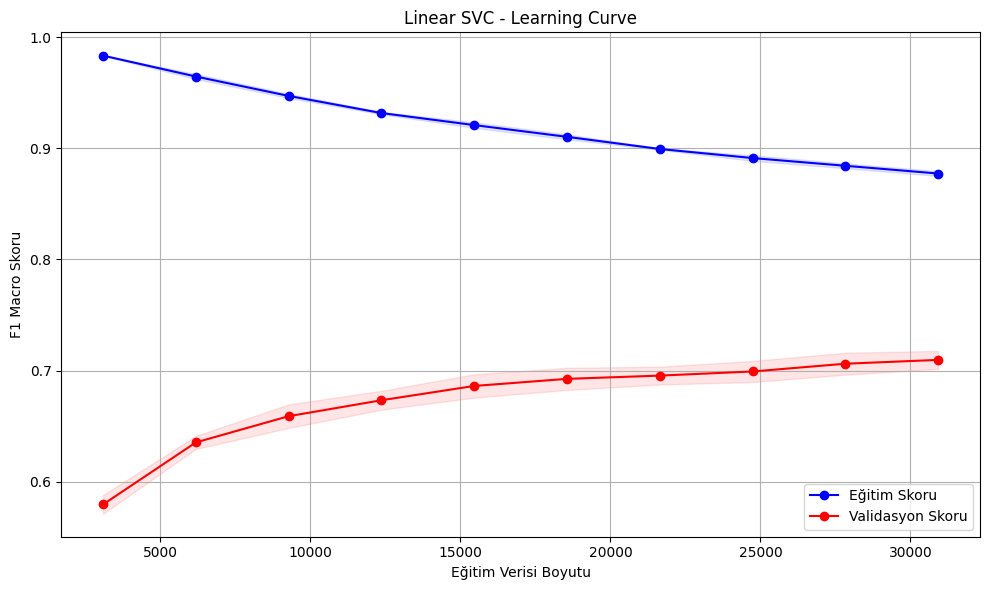

In [ ]:
from sklearn.model_selection import learning_curve

train_sizes, train_scores, test_scores = learning_curve(
    LinearSVC(C=1, max_iter=1000, class_weight='balanced'),
    X_train_selected, y_train,
    cv=5,
    scoring='f1_macro',
    train_sizes=np.linspace(0.1, 1.0, 10),
    n_jobs=-1
)

train_mean = np.mean(train_scores, axis=1)
train_std = np.std(train_scores, axis=1)
test_mean = np.mean(test_scores, axis=1)
test_std = np.std(test_scores, axis=1)

plt.figure(figsize=(10, 6))
plt.plot(train_sizes, train_mean, 'o-', color='blue', label='Eğitim Skoru')
plt.plot(train_sizes, test_mean, 'o-', color='red', label='Validasyon Skoru')
plt.fill_between(train_sizes, train_mean - train_std, train_mean + train_std, alpha=0.1, color='blue')
plt.fill_between(train_sizes, test_mean - test_std, test_mean + test_std, alpha=0.1, color='red')
plt.title('Linear SVC - Learning Curve')
plt.xlabel('Eğitim Verisi Boyutu')
plt.ylabel('F1 Macro Skoru')
plt.legend(loc='lower right')
plt.grid(True)
plt.tight_layout()
plt.show()